<a href="https://colab.research.google.com/github/leo7812/CA-WildFire-ML-Models/blob/main/CS163_Weather_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# all my weather files should be in folder WildFireFiles

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
folder_path = '/content/drive/MyDrive/WildFireFiles/'

In [ ]:
folder_path

'/content/drive/MyDrive/WildFireFiles/'

In [ ]:
folder_path = '/content/drive/MyDrive/WildFireFiles/'
file_name = 'California_Historic_Fire_Perimeters_1980-2025.csv'
wildfire_df = pd.read_csv(folder_path + file_name)

In [ ]:
wildfire_df.head()

,OBJECTID,Year,State,Agency,Unit ID,Fire Name,Local Incident Number,Alarm Date,Containment Date,Cause,...,Management Objective,GIS Calculated Acres,Comments,Complex Name,IRWIN ID,Fire Number (historical use),Complex ID,DECADES,Shape__Area,Shape__Length
0,1,2025.0,CA,CDF,LDF,PALISADES,00000738,1/7/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,23448.8800,NaN,NaN,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},NaN,NaN,2020-January 2025,1.386518e+08,140231.608232
1,2,2025.0,CA,CDF,LAC,EATON,00009087,1/8/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,14056.2600,NaN,NaN,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},NaN,NaN,2020-January 2025,8.336393e+07,104933.207224
2,3,2025.0,CA,CDF,ANF,HUGHES,00250270,1/22/2025 8:00:00 AM,1/28/2025 8:00:00 AM,14,...,1.0,10396.8000,NaN,NaN,{994072D2-E154-434A-BB95-6F6C94C40829},NaN,NaN,2020-January 2025,6.216064e+07,96698.599858
3,4,2025.0,CA,CCO,VNC,KENNETH,00003155,1/9/2025 8:00:00 AM,2/4/2025 8:00:00 AM,14,...,1.0,998.7378,from OES Intel 24,NaN,{842FB37B-7AC8-4700-BB9C-028BF753D149},NaN,NaN,2020-January 2025,5.919678e+06,15602.004849
4,5,2025.0,CA,CDF,LDF,HURST,00003294,1/7/2025 8:00:00 AM,1/9/2025 8:00:00 AM,14,...,1.0,831.3855,NaN,NaN,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},NaN,NaN,2020-January 2025,4.946082e+06,16094.217073


In [ ]:
wildfire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22810 entries, 0 to 22809
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OBJECTID                      22810 non-null  int64  
 1   Year                          22733 non-null  float64
 2   State                         22810 non-null  object 
 3   Agency                        22761 non-null  object 
 4   Unit ID                       22749 non-null  object 
 5   Fire Name                     22638 non-null  object 
 6   Local Incident Number         21839 non-null  object 
 7   Alarm Date                    17414 non-null  object 
 8   Containment Date              10180 non-null  object 
 9   Cause                         22810 non-null  int64  
 10  Collection Method             10708 non-null  float64
 11  Management Objective          22539 non-null  float64
 12  GIS Calculated Acres          22810 non-null  float64
 13  C

In [ ]:
# Shape_Area is measured in squared meters I believe, due it being the standard for CA Web Mercator projection
# GIS Calculated Acres would be more reliable as it is the actual size of fire

In [ ]:
weather_conditions_df = pd.read_csv(folder_path + 'CA_Weather_Fire_Dataset_1984-2025-WeatherConditionsDaysOfFire.csv')

In [ ]:
weather_conditions_df.head(10)

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5
5,1984-01-06,0.0,65.0,49.0,7.38,False,1984,16.0,0.113538,1,Winter,0.0,5.480000,6
6,1984-01-07,0.0,59.0,54.0,5.82,False,1984,5.0,0.098644,1,Winter,0.0,5.528571,7
7,1984-01-08,0.0,59.0,55.0,3.36,False,1984,4.0,0.056949,1,Winter,0.0,5.337143,8
8,1984-01-09,0.0,61.0,54.0,6.71,False,1984,7.0,0.110000,1,Winter,0.0,5.497143,9
9,1984-01-10,0.0,70.0,47.0,4.70,False,1984,23.0,0.067143,1,Winter,0.0,5.401429,10


In [ ]:
weather_conditions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DATE                   14988 non-null  object 
 1   PRECIPITATION          14987 non-null  float64
 2   MAX_TEMP               14987 non-null  float64
 3   MIN_TEMP               14987 non-null  float64
 4   AVG_WIND_SPEED         14976 non-null  float64
 5   FIRE_START_DAY         14988 non-null  bool   
 6   YEAR                   14988 non-null  int64  
 7   TEMP_RANGE             14987 non-null  float64
 8   WIND_TEMP_RATIO        14976 non-null  float64
 9   MONTH                  14988 non-null  int64  
 10  SEASON                 14988 non-null  object 
 11  LAGGED_PRECIPITATION   14988 non-null  float64
 12  LAGGED_AVG_WIND_SPEED  14988 non-null  float64
 13  DAY_OF_YEAR            14988 non-null  int64  
dtypes: bool(1), float64(8), int64(3), object(2)
memory usa

In [ ]:
wc_df = weather_conditions_df


In [ ]:
fireDates = wc_df[wc_df['FIRE_START_DAY'] == True]

In [ ]:
fireDates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4971 entries, 26 to 14600
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DATE                   4971 non-null   object 
 1   PRECIPITATION          4971 non-null   float64
 2   MAX_TEMP               4971 non-null   float64
 3   MIN_TEMP               4971 non-null   float64
 4   AVG_WIND_SPEED         4971 non-null   float64
 5   FIRE_START_DAY         4971 non-null   bool   
 6   YEAR                   4971 non-null   int64  
 7   TEMP_RANGE             4971 non-null   float64
 8   WIND_TEMP_RATIO        4971 non-null   float64
 9   MONTH                  4971 non-null   int64  
 10  SEASON                 4971 non-null   object 
 11  LAGGED_PRECIPITATION   4971 non-null   float64
 12  LAGGED_AVG_WIND_SPEED  4971 non-null   float64
 13  DAY_OF_YEAR            4971 non-null   int64  
dtypes: bool(1), float64(8), int64(3), object(2)
memory usage: 5

In [ ]:
fireDates.head()

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
26,1984-01-27,0.0,79.0,57.0,8.50,True,1984,22.0,0.107595,1,Winter,0.00,7.222857,27
79,1984-03-20,0.0,76.0,58.0,6.71,True,1984,18.0,0.088289,3,Spring,0.14,8.691429,80
82,1984-03-23,0.0,77.0,54.0,7.38,True,1984,23.0,0.095844,3,Spring,0.00,7.477143,83
88,1984-03-29,0.0,71.0,53.0,11.41,True,1984,18.0,0.160704,3,Spring,0.00,7.988571,89
102,1984-04-12,0.0,73.0,53.0,5.14,True,1984,20.0,0.070411,4,Spring,0.87,7.347143,103


Text(0.5, 1.0, 'Distribution of Max Temp: Fire vs. Non-Fire Days')

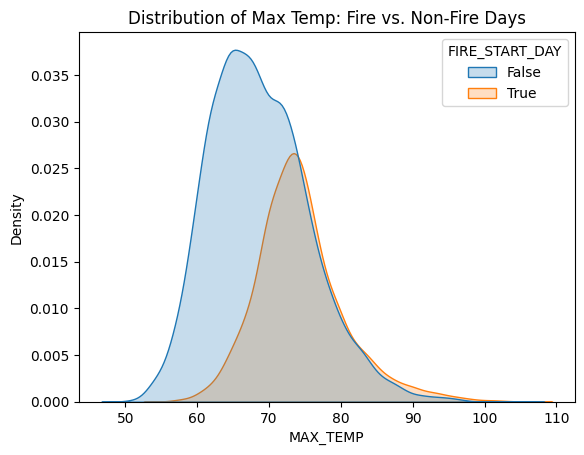

In [ ]:
sns.kdeplot(data=wc_df, x="MAX_TEMP", hue="FIRE_START_DAY", fill=True)
plt.title("Distribution of Max Temp: Fire vs. Non-Fire Days")
# shows day temperatures of days with fire vs days without fires

In [ ]:
# 1. Clean the Wildfire Dates
# Convert 'Alarm Date' to datetime. errors='coerce' handles any weirdly formatted rows by turning them into NaT (Not a Time)
wildfire_df['Parsed_Alarm_Date'] = pd.to_datetime(wildfire_df['Alarm Date'], errors='coerce')

# Create a new column with just the date (stripping the time) to match the weather dataset
wildfire_df['Join_Date'] = pd.to_datetime(wildfire_df['Parsed_Alarm_Date'].dt.date)

# 2. Clean the Weather Dates
# Ensure the weather DATE column is also a standard datetime object
wc_df['Join_Date'] = pd.to_datetime(wc_df['DATE'])

# 3. Merge the Datasets
# We'll use an 'inner' merge to only keep records where we have BOTH a fire perimeter and the weather for that day
merged_fire_weather_df = pd.merge(wildfire_df, wc_df, on='Join_Date', how='inner')

merged_fire_weather_df[['Fire Name', 'Join_Date', 'GIS Calculated Acres', 'MAX_TEMP', 'AVG_WIND_SPEED']].head()

,Fire Name,Join_Date,GIS Calculated Acres,MAX_TEMP,AVG_WIND_SPEED
0,PALISADES,2025-01-07,23448.8800,73.0,13.42
1,EATON,2025-01-08,14056.2600,73.0,10.51
2,KENNETH,2025-01-09,998.7378,68.0,4.92
3,HURST,2025-01-07,831.3855,73.0,13.42
4,LIDIA,2025-01-08,347.7042,73.0,10.51


In [ ]:
merged_fire_weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11166 entries, 0 to 11165
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   OBJECTID                      11166 non-null  int64         
 1   Year                          11166 non-null  float64       
 2   State                         11166 non-null  object        
 3   Agency                        11165 non-null  object        
 4   Unit ID                       11153 non-null  object        
 5   Fire Name                     11147 non-null  object        
 6   Local Incident Number         10752 non-null  object        
 7   Alarm Date                    11166 non-null  object        
 8   Containment Date              9275 non-null   object        
 9   Cause                         11166 non-null  int64         
 10  Collection Method             9338 non-null   float64       
 11  Management Objective        

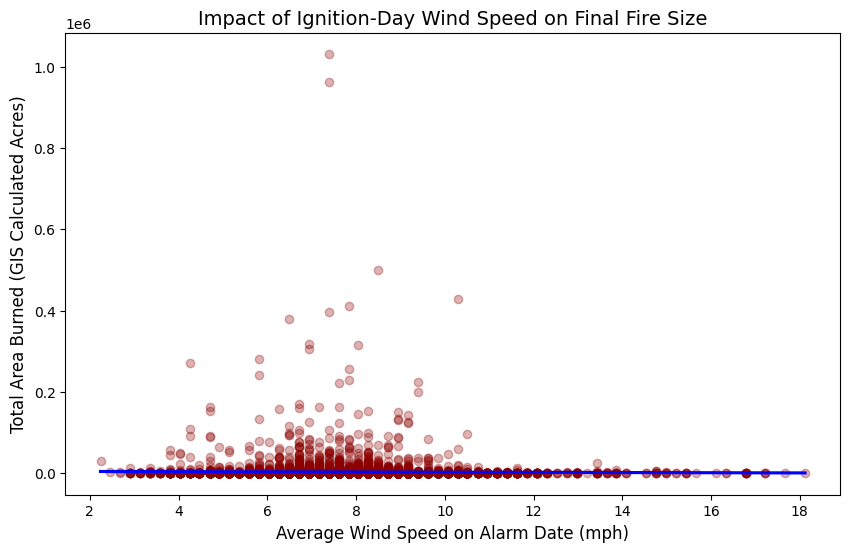

In [ ]:
plt.figure(figsize=(10, 6))

# Use seaborn's regplot to plot the scatter points and a line of best fit
sns.regplot(
    data=merged_fire_weather_df,
    x='AVG_WIND_SPEED',
    y='GIS Calculated Acres',
    scatter_kws={'alpha': 0.3, 'color': 'darkred'}, # alpha makes points semi-transparent to see clusters
    line_kws={'color': 'blue'} # Color the trendline blue
)

plt.title('Impact of Ignition-Day Wind Speed on Final Fire Size', fontsize=14)
plt.xlabel('Average Wind Speed on Alarm Date (mph)', fontsize=12)
plt.ylabel('Total Area Burned (GIS Calculated Acres)', fontsize=12)

plt.show()

In [ ]:
#plt.yscale('log')
# for scaling to display smaller fires

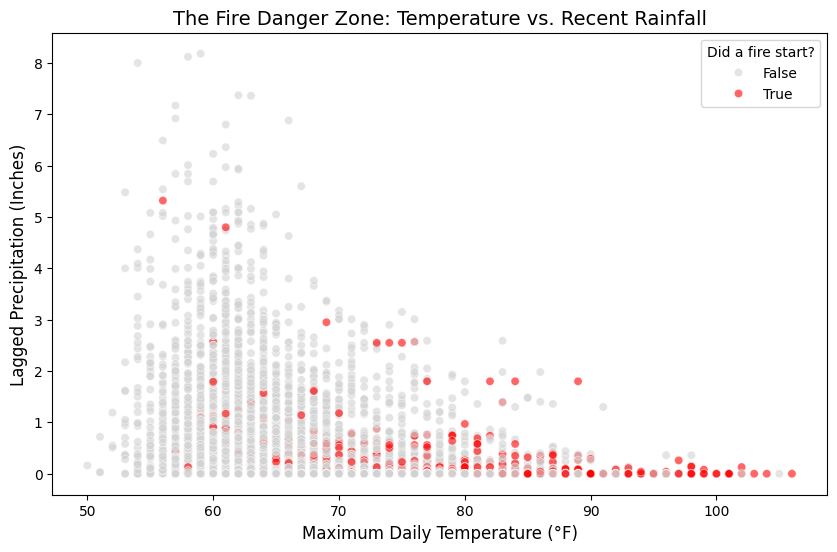

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot of Temp vs. Precipitation, colored by whether a fire started
sns.scatterplot(
    data=wc_df,
    x='MAX_TEMP',
    y='LAGGED_PRECIPITATION',
    hue='FIRE_START_DAY',
    palette={True: 'red', False: 'lightgrey'},
    alpha=0.6
)

plt.title('The Fire Danger Zone: Temperature vs. Recent Rainfall', fontsize=14)
plt.xlabel('Maximum Daily Temperature (°F)', fontsize=12)
plt.ylabel('Lagged Precipitation (Inches)', fontsize=12)

plt.legend(title='Did a fire start?', loc='upper right')
plt.show()

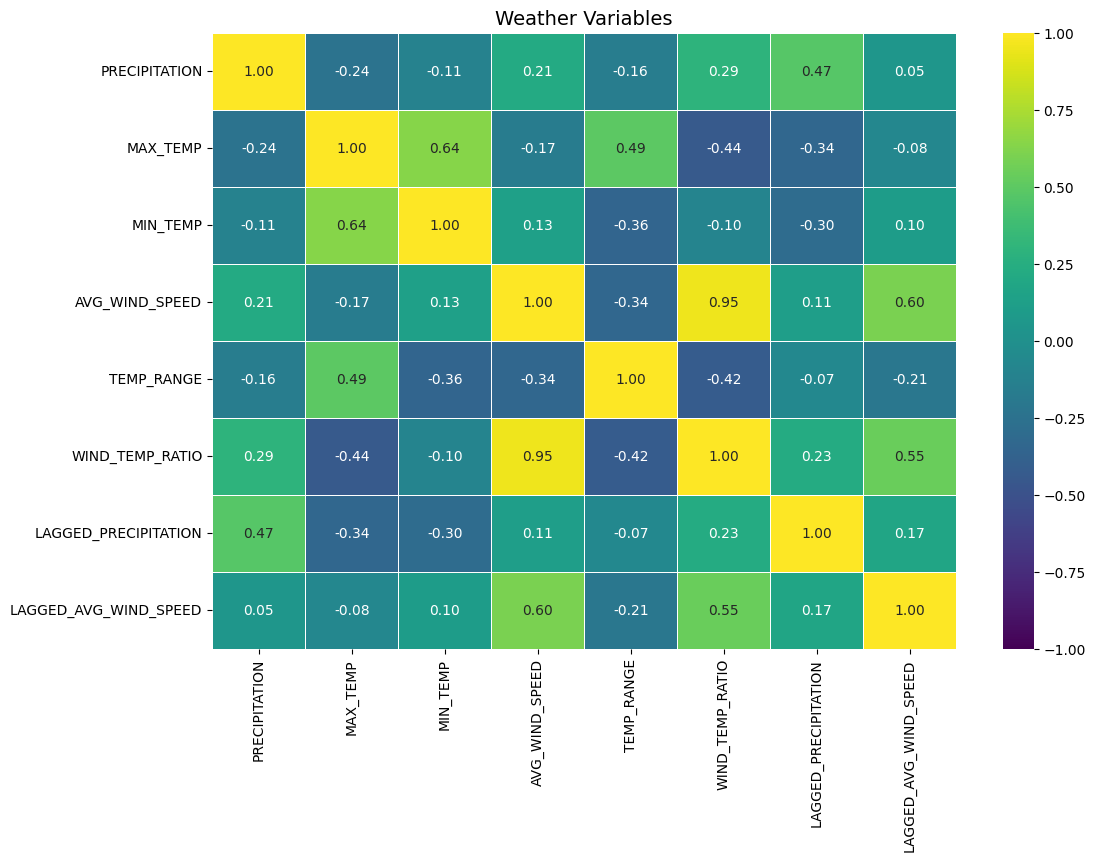

In [ ]:
plt.figure(figsize=(12, 8))

#  only the numerical weather columns
weather_numeric = wc_df[['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP',
                         'AVG_WIND_SPEED', 'TEMP_RANGE', 'WIND_TEMP_RATIO',
                         'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED']]

sns.heatmap(
    weather_numeric.corr(),
    annot=True,
    cmap='viridis',  # Using a different color map for variety
    fmt=".2f",
    vmin=-1, vmax=1, # Lock the scale from -1 to 1
    linewidths=0.5
)

plt.title('Weather Variables', fontsize=14)
plt.show()